In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

df = pd.read_csv("..\Data\processed\cleaned_data.csv")
df.head() 

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Is_Zero_Balance,Balance_Salary_Ratio,Tenure_Age_Ratio,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0.000000,0.047619,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0.744670,0.024390,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,1.401362,0.190476,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0.000000,0.025641,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1.587035,0.046512,False,True


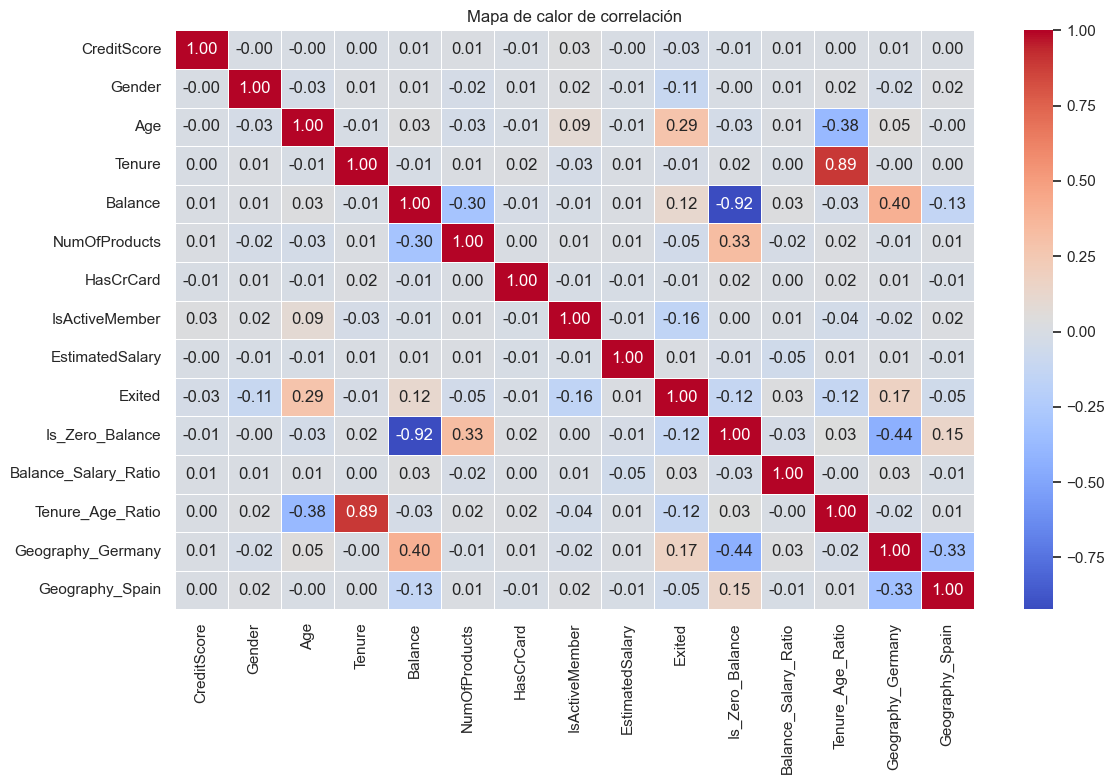

In [ ]:
# Mapa de calor de correlación
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de calor de correlación")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

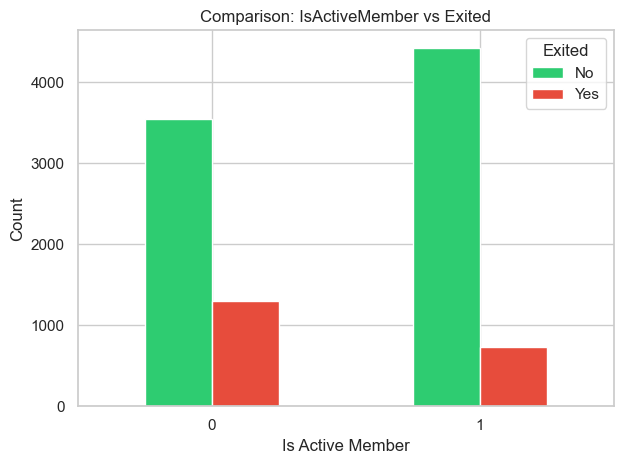

In [ ]:
# Creamos una tabla de contingencia para comparar 'IsActiveMember' y 'Exited'
comparison = pd.crosstab(df['IsActiveMember'], df['Exited'])

# Visualizamos la comparación con un gráfico de barras
plt.figure(figsize=(10, 6))
comparison.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.xlabel('Is Active Member')
plt.ylabel('Count')
plt.title('Comparison: IsActiveMember vs Exited')
plt.legend(title='Exited', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Balance value counts:
0.00         3617
130170.82       2
105473.74       2
85304.27        1
159397.75       1
144238.70       1
112262.84       1
109106.80       1
142147.32       1
109109.33       1
Name: Balance, dtype: int64


Clients with Balance = 0.00: 3617
Percentage: 36.17%


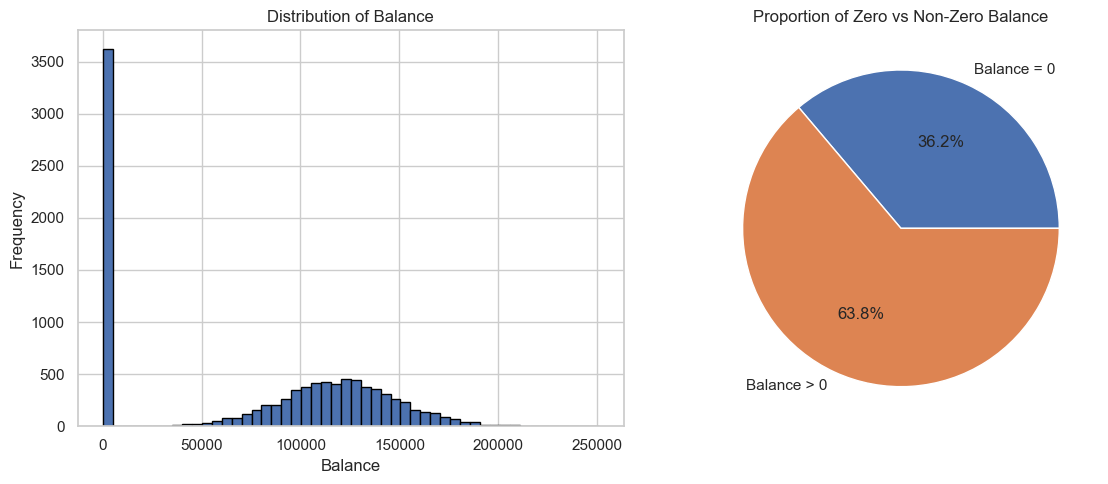

In [ ]:
# Análisis de la variable 'Balance'
print("Balance value counts:")
print(df['Balance'].value_counts().head(10))
print("\n")
print(f"Clients with Balance = 0.00: {(df['Balance'] == 0).sum()}")
print(f"Percentage: {(df['Balance'] == 0).sum() / len(df) * 100:.2f}%")

# Visualización de la distribución de 'Balance' y proporción de clientes con Balance = 0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Balance'].hist(bins=50, edgecolor='black')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.title('Distribution of Balance')

plt.subplot(1, 2, 2)
balance_zero = (df['Balance'] == 0).sum()
balance_nonzero = (df['Balance'] != 0).sum()
plt.pie([balance_zero, balance_nonzero], labels=['Balance = 0', 'Balance > 0'], autopct='%1.1f%%')
plt.title('Proportion of Zero vs Non-Zero Balance')
plt.tight_layout()
plt.show()

In [ ]:
# Analizamos la tasa de fuga (churn) entre clientes con Balance = 0 y Balance > 0
# - 0 indica que el cliente tiene un balance de 0 (Cuenta Zombie)
# - 1 indica que el cliente tiene un balance mayor a 0
tasa_fuga = df.groupby('Is_Zero_Balance')['Exited'].mean()
print("Tasa de fuga por tipo de balance:")
print(tasa_fuga)

Tasa de fuga por tipo de balance:
Is_Zero_Balance
0    0.240796
1    0.138236
Name: Exited, dtype: float64


## Hallazgos Críticos del Análisis Exploratorio (EDA)

#### 1. El factor demográfico: Edad (Age)
- **Insight:** Se observa una correlación positiva significativa entre la edad y la tasa de abandono (`Exited`). 
- **Interpretación:** Los clientes en el rango de **40 a 60 años** muestran una mayor tendencia a abandonar el banco en comparación con los segmentos más jóvenes. Esto sugiere que el banco podría estar perdiendo clientes en su etapa de mayor estabilidad financiera.

#### 2. El fenómeno de las "Cuentas Zombie": Balance Cero
- **Insight:** El **36.2%** de los clientes mantienen un saldo de 0.00.
- **Interpretación:** Este grupo representa un riesgo operativo. No necesariamente han cerrado su cuenta (churn oficial), pero están en un estado de "inactividad financiera". Tratarlos igual que a los clientes con saldo positivo sesgaría el modelo.

## Preparación para el Modelado Predictivo

Basado en el análisis de correlación y distribución:
1. **Manejo de Desbalance:** Dado que solo el ~20% de los datos corresponden a fugas, se utilizarán técnicas de pesaje de clases (`class_weight='balanced'`) en el entrenamiento.
2. **Segmentación Geográfica:** Se observó que la región de **Alemania** tiene una tasa de abandono proporcionalmente más alta, lo que justifica mantener las variables `Geography` mediante One-Hot Encoding para capturar diferencias territoriales.